In [8]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.resnet50 import preprocess_input

In [87]:
resnet50_model = tf.keras.models.load_model(
    "../models/resnet50_model_final.keras"
)


In [88]:


image_path = "/home/aximsoft/PycharmProjects/Weekend-Task/SkinCancer_Disease/dataset/ham10000_images_part_1/ISIC_0024325.jpg"

image = cv2.imread(image_path)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

image = cv2.resize(
    image,
    (224,224)
)

# Keep a copy for display
display_image = image.copy()

image = image.astype("float32")

image = preprocess_input(image)

input_image = np.expand_dims(
    image,
    axis=0
)

In [89]:
prediction = resnet50_model.predict(input_image)

predicted_class = np.argmax(prediction)

confidence = np.max(prediction)

print("Predicted Class :", predicted_class)
print("Confidence :", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class : 5
Confidence : 0.9531919


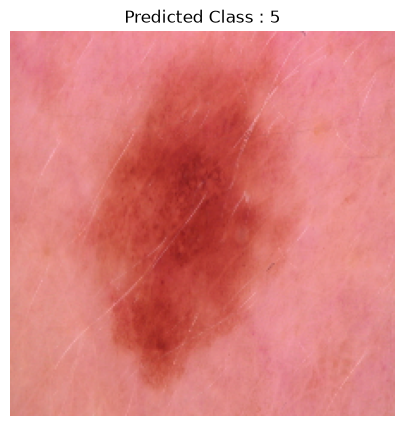

In [90]:
plt.figure(figsize=(5,5))

plt.imshow(display_image)

plt.title(f"Predicted Class : {predicted_class}")

plt.axis("off")

plt.show()

In [91]:
for i, layer in enumerate(resnet50_model.layers):
    print(i, layer.name, layer.output.shape)

0 resnet50 (None, 7, 7, 2048)
1 global_average_pooling2d (None, 2048)
2 dense (None, 512)
3 dropout (None, 512)
4 dense_1 (None, 7)


In [92]:
print(resnet50_model.built)
print(resnet50_model.inputs)

True
[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_2>]


In [93]:
for layer in resnet50_model.layers:
    print(layer.name, type(layer))

resnet50 <class 'keras.src.models.functional.Functional'>
global_average_pooling2d <class 'keras.src.layers.pooling.global_average_pooling2d.GlobalAveragePooling2D'>
dense <class 'keras.src.layers.core.dense.Dense'>
dropout <class 'keras.src.layers.regularization.dropout.Dropout'>
dense_1 <class 'keras.src.layers.core.dense.Dense'>


In [94]:
base_resnet = resnet50_model.get_layer("resnet50")

feature_model = tf.keras.Model(
    inputs=base_resnet.input,
    outputs=base_resnet.output
)

In [95]:
feature_model.summary()

Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [96]:
feature_maps = feature_model.predict(
    input_image
)

print(feature_maps.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
(1, 7, 7, 2048)


In [97]:
filter_strength = np.mean(
    feature_maps[0],
    axis=(0,1)
)

top_filters = np.argsort(
    filter_strength
)[-16:]

print(top_filters)

[ 575 1863  313  554  878  624 1868  884 1255  919  762 1644 1023  227
 1988 1248]


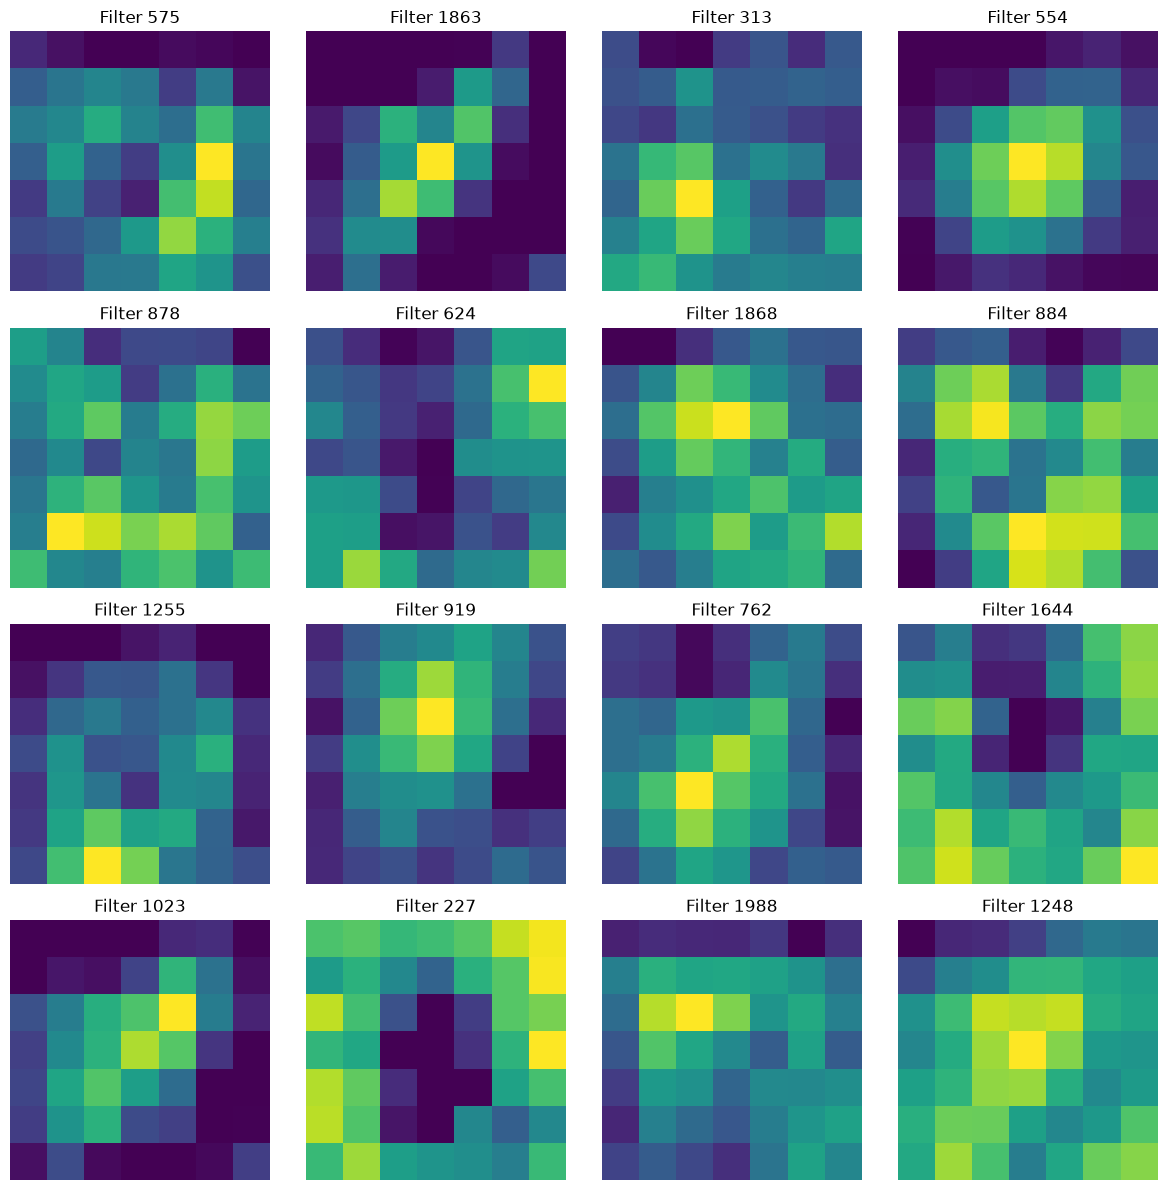

In [98]:
plt.figure(figsize=(12,12))

for i, idx in enumerate(top_filters):

    plt.subplot(4,4,i+1)

    plt.imshow(
        feature_maps[0,:,:,idx],
        cmap="viridis"
    )

    plt.title(f"Filter {idx}")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [99]:
input_image.shape

(1, 224, 224, 3)

In [100]:
def create_saliency_map(model, image):

    image = tf.convert_to_tensor(
        image
    )

    with tf.GradientTape() as tape:

        tape.watch(image)

        prediction = model(image)

        class_index = tf.argmax(
            prediction[0]
        )

        class_output = prediction[:, class_index]


    gradients = tape.gradient(
        class_output,
        image
    )


    saliency = tf.reduce_max(
        tf.abs(gradients),
        axis=-1
    )


    saliency = saliency.numpy()[0]


    saliency = (
        saliency - saliency.min()
    ) / (
        saliency.max() - saliency.min()
    )

    return saliency

In [101]:
saliency_map = create_saliency_map(
    resnet50_model,
    input_image
)

print(saliency_map.shape)

(224, 224)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-87.779..125.32].


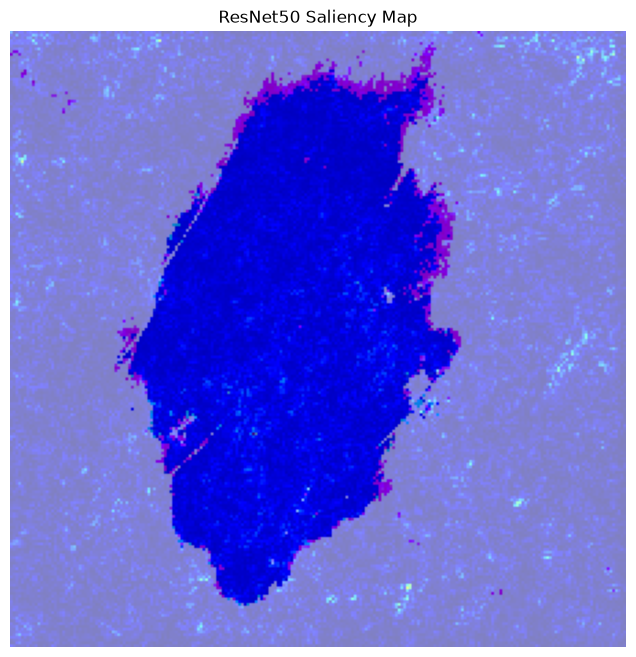

In [102]:
plt.figure(figsize=(8,8))

plt.imshow(
    input_image[0]
)

plt.imshow(
    saliency_map,
    cmap="jet",
    alpha=0.5
)

plt.title(
    "ResNet50 Saliency Map"
)

plt.axis("off")

plt.show()

In [103]:
last_conv_layer_name = "conv5_block3_out"

In [105]:
input_image.shape

(1, 224, 224, 3)

In [106]:
img_array = input_image

print(img_array.shape)

(1, 224, 224, 3)


In [107]:
base_resnet = resnet50_model.get_layer("resnet50")

print(type(base_resnet))

<class 'keras.src.models.functional.Functional'>


In [108]:
for layer in base_resnet.layers:
    if "conv5" in layer.name:
        print(layer.name)

conv5_block1_1_conv
conv5_block1_1_bn
conv5_block1_1_relu
conv5_block1_2_conv
conv5_block1_2_bn
conv5_block1_2_relu
conv5_block1_0_conv
conv5_block1_3_conv
conv5_block1_0_bn
conv5_block1_3_bn
conv5_block1_add
conv5_block1_out
conv5_block2_1_conv
conv5_block2_1_bn
conv5_block2_1_relu
conv5_block2_2_conv
conv5_block2_2_bn
conv5_block2_2_relu
conv5_block2_3_conv
conv5_block2_3_bn
conv5_block2_add
conv5_block2_out
conv5_block3_1_conv
conv5_block3_1_bn
conv5_block3_1_relu
conv5_block3_2_conv
conv5_block3_2_bn
conv5_block3_2_relu
conv5_block3_3_conv
conv5_block3_3_bn
conv5_block3_add
conv5_block3_out


In [109]:
print(resnet50_model.name)
print(type(resnet50_model))

sequential_1
<class 'keras.src.models.sequential.Sequential'>


In [110]:

print(type(resnet50_model))

<class 'keras.src.models.sequential.Sequential'>


In [111]:
print(type(resnet50_model))

<class 'keras.src.models.sequential.Sequential'>


In [112]:
for layer in resnet50_model.layers:
    print(layer.name)

resnet50
global_average_pooling2d
dense
dropout
dense_1


In [113]:
base_resnet = resnet50_model.get_layer("resnet50")

print(type(base_resnet))

<class 'keras.src.models.functional.Functional'>


In [114]:
print(resnet50_model.inputs)

[<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_2>]


In [115]:
resnet50_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,693,072 (98.01 MB)

 Trainable params: 1,052,679 (4.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

 Optimizer params: 1,052,681 (4.02 MB)

In [116]:
base_resnet = resnet50_model.get_layer("resnet50")

gap = resnet50_model.get_layer(
    "global_average_pooling2d"
)

dense1 = resnet50_model.get_layer(
    "dense"
)

dropout = resnet50_model.get_layer(
    "dropout"
)

dense2 = resnet50_model.get_layer(
    "dense_1"
)

In [ ]:
def make_gradcam_heatmap(
    img_array,
    base_resnet,
    gap,
    dense1,
    dropout,
    dense2,
    last_conv_layer_name,
    pred_index=None
):

    grad_model = tf.keras.models.Model(
        inputs=base_resnet.input,
        outputs=[
            base_resnet.get_layer(last_conv_layer_name).output,
            base_resnet.output
        ]
    )


    with tf.GradientTape() as tape:

        conv_outputs, features = grad_model(img_array)


        x = gap(features)
        x = dense1(x)
        x = dropout(x, training=False)

        predictions = dense2(x)


        if pred_index is None:
            pred_index = tf.argmax(
                predictions[0]
            )


        class_channel = predictions[:, pred_index]


    grads = tape.gradient(
        class_channel,
        conv_outputs
    )


    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )


    conv_outputs = conv_outputs[0]


    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]


    heatmap = tf.squeeze(
        heatmap
    )


    heatmap = tf.maximum(
        heatmap,
        0
    ) / tf.reduce_max(
        heatmap
    )


    return heatmap.numpy()

In [118]:
heatmap = make_gradcam_heatmap(
    img_array,
    base_resnet,
    gap,
    dense1,
    dropout,
    dense2,
    "conv5_block3_out"
)

print(heatmap.shape)

(7, 7)


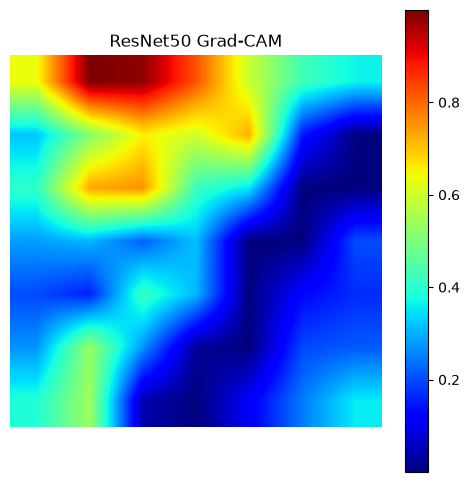

In [119]:
heatmap = cv2.resize(
    heatmap,
    (224,224)
)

plt.figure(figsize=(6,6))

plt.imshow(
    heatmap,
    cmap="jet"
)

plt.colorbar()

plt.title("ResNet50 Grad-CAM")

plt.axis("off")

plt.show()

In [120]:
def overlay_gradcam(image, heatmap, alpha=0.4):

    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(
        heatmap,
        cv2.COLORMAP_JET
    )

    heatmap = cv2.cvtColor(
        heatmap,
        cv2.COLOR_BGR2RGB
    )

    image = np.uint8(
        image * 255
    )

    overlay = cv2.addWeighted(
        image,
        1-alpha,
        heatmap,
        alpha,
        0
    )

    return overlay

In [121]:
gradcam_overlay = overlay_gradcam(
    input_image[0],
    heatmap
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-87.779..125.32].


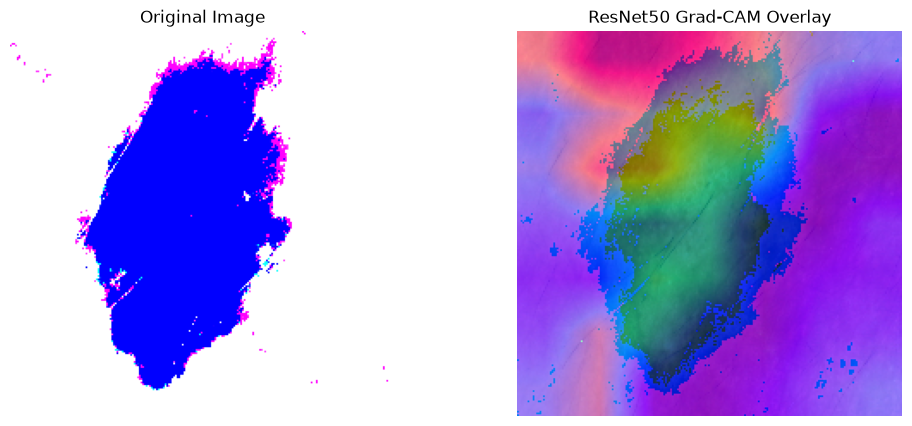

In [122]:
plt.figure(figsize=(12,5))


plt.subplot(1,2,1)

plt.imshow(
    input_image[0]
)

plt.title("Original Image")

plt.axis("off")



plt.subplot(1,2,2)

plt.imshow(
    gradcam_overlay
)

plt.title(
    "ResNet50 Grad-CAM Overlay"
)

plt.axis("off")


plt.show()